In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("TensorFlow is installed successfully!")

TensorFlow version: 2.22.0-dev20260921
TensorFlow is installed successfully!


In [2]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

# Check available GPUs
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("CUDA/GPU is available ✅")
    print("GPUs:", gpus)
else:
    print("CUDA/GPU is NOT available ❌")

TensorFlow version: 2.22.0-dev20260921
CUDA/GPU is NOT available ❌


In [3]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler , OneHotEncoder

from sklearn.model_selection import train_test_split

In [4]:
data = pd.read_csv(r"C:\Users\shahh\OneDrive\Desktop\Data Science And Machine Learning\Assignments\Assignment07\Iris.csv")
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
X = data.drop(["Id","Species"], axis =1).to_numpy()
y = data[["Species"]].to_numpy()

In [6]:
scaler  = StandardScaler()
onehot_encoder = OneHotEncoder(sparse_output = False)

enc_y = onehot_encoder.fit_transform(y)
scaled_X = scaler.fit_transform(X)

In [7]:
cat_array = onehot_encoder.categories_[0]

In [8]:
X_train, X_test , y_train, y_test = train_test_split(
    scaled_X, enc_y, test_size = 0.2, shuffle = True, stratify = enc_y, random_state = 999
)

Model Creation and Compile

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import SGD, Adam

In [10]:
inp_shape = X_train.shape[1]
num_classes = y_train.shape[1]

In [11]:
model = Sequential()
model.add(Input(shape = (inp_shape,)))  # Input Layer

model.add(Dense(10, activation = "relu"))   # hidden layer
model.add(Dense(6, activation = "relu")) # hidden layer

model.add(Dense(num_classes, activation = "softmax"))# output layer

model.compile(
    optimizer = Adam(learning_rate = 0.1),
    loss = "categorical_crossentropy",
    metrics = ["accuracy"]
)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │            66 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137 (548.00 B)

 Trainable params: 137 (548.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    X_train, y_train, epochs = 50, batch_size = 64, verbose = 1
)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3333 - loss: 1.1000 
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6750 - loss: 0.6252
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7583 - loss: 0.4845
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8333 - loss: 0.3877
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8667 - loss: 0.3296
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8833 - loss: 0.2800
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9250 - loss: 0.2356
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9583 - loss: 0.1931
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9417 - loss: 0.1419
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9500 - loss: 0.1093
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9750 - loss: 0.1061
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9583 - loss: 0.0895


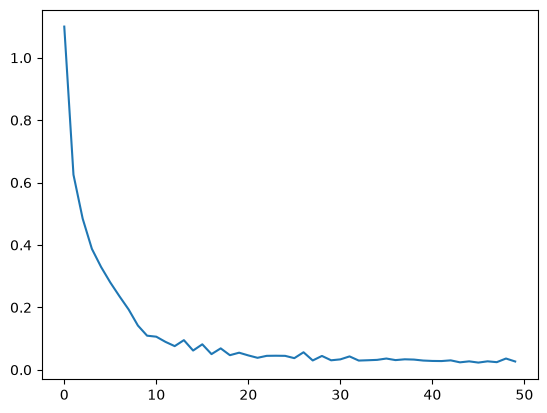

In [14]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"])

In [15]:
loss, accuracy = model.evaluate(X_test, y_test)
accuracy

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9667 - loss: 0.0837


0.9666666388511658

In [16]:
y_pred = np.argmax(model.predict(X_test), axis=1)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


array([2, 2, 2, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 2, 2, 1, 1, 0, 1, 2,
       1, 2, 0, 1, 2, 1, 0, 2])

In [17]:
y_true = np.argmax(y_test, axis=1)
y_true

array([2, 2, 2, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 2, 1, 2, 2, 1, 1, 0, 1, 2,
       1, 2, 0, 1, 2, 1, 0, 2])

In [18]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

In [19]:
print("Confusion Matrix\n",confusion_matrix(y_true, y_pred))

Confusion Matrix
 [[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]


In [20]:
print("Accuracy",accuracy_score(y_true, y_pred))

Accuracy 0.9666666666666667


In [21]:
print("Precision:", precision_score(y_true, y_pred, average="macro"))
print("Recall   :", recall_score(y_true, y_pred, average="macro"))
print("F1 Score :", f1_score(y_true, y_pred, average="macro"))

Precision: 0.9696969696969697
Recall   : 0.9666666666666667
F1 Score : 0.9665831244778613


In [23]:
cat_array[np.argmax(model.predict(
    np.array([[5.1, 3.5, 1.4, 0.2]])
))]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


'Iris-versicolor'

In [25]:
model.save("iris_classifier.keras")

In [ ]:
import pickle # joblib 

In [26]:
import pickle

to_package = {
    "scaler": scaler,
    "encoder": onehot_encoder,
    "model": model
}

with open("iris_classifier.pkl", "wb") as f:
    pickle.dump(to_package, f)